In [7]:
import numpy as np
from heapq import heappush, heappop # para usar com o algoritmo Watershed
import cv2
from matplotlib import pyplot as plt

# OTSU


In [16]:

# Versão mais from scratch

def otsu_threshold_manual(image):
    hist = np.bincount(image.ravel(), minlength=256)
    total = image.size

    sum_total = np.sum(np.arange(256) * hist)

    sum_b = 0
    weight_b = 0
    max_variance = 2
    threshold = 0

    for t in range(256):
        weight_b += hist[t]
        if weight_b == 0:
            continue

        weight_f = total - weight_b
        if weight_f == 0:
            break

        sum_b += t * hist[t]

        mean_b = sum_b / weight_b
        mean_f = (sum_total - sum_b) / weight_f

        # Variância entre classes
        var_between = weight_b * weight_f * (mean_b - mean_f) ** 2

        if var_between > max_variance:
            max_variance = var_between
            threshold = t

    return threshold

def apply_threshold(image, threshold):
    return (image >= threshold).astype(np.uint8) * 255


Threshold ótimo: 102


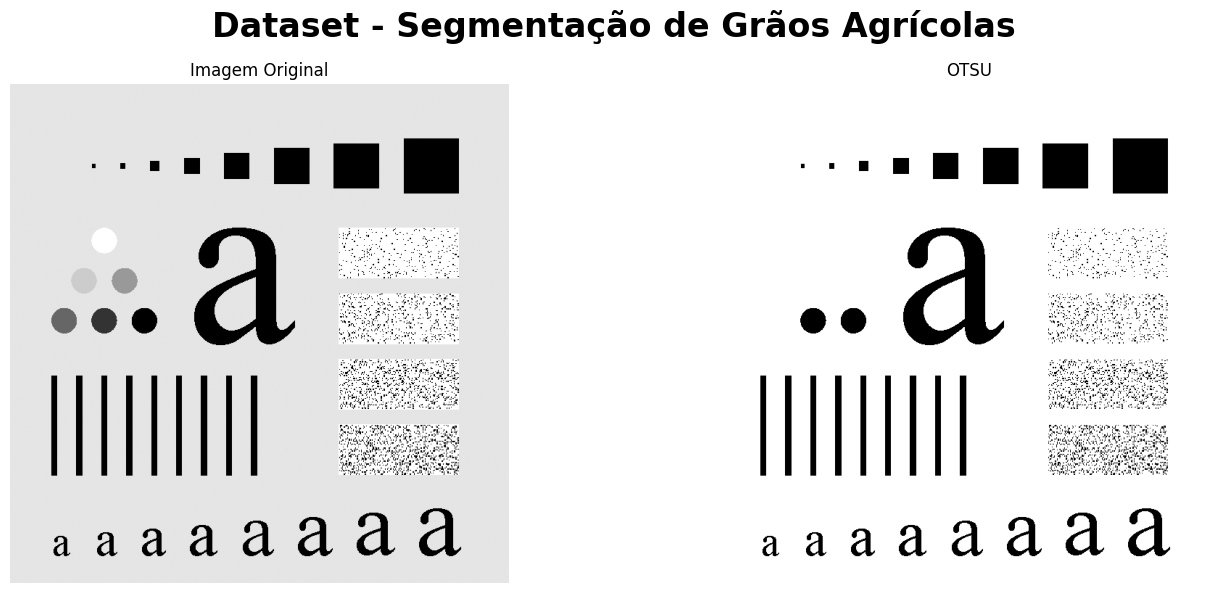

In [18]:
image = np.zeros((100, 100), dtype=np.uint8)
image[:, :50] = 50     # fundo escuro
image[:, 50:] = 200    # objeto claro
img_path = 'data/test/aa.png'
#img_path = 'data/dataset_seeds/0001.jpg' #'data/test/aa.png'
img = cv2.cvtColor(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB), cv2.COLOR_RGB2GRAY) 
# Calcula threshold
t = otsu_threshold_manual(img)
print("Threshold ótimo:", t)

# Binariza
binary = apply_threshold(img, t)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Dataset - Segmentação de Grãos Agrícolas" , fontsize=24, fontweight='bold')

axes[0].imshow(img, cmap='gray')
axes[0].set_title(f'Imagem Original')
axes[0].axis('off')

axes[1].imshow(binary, cmap='gray')
axes[1].set_title(f'OTSU')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# SELIC - SuperPixel


 SLIC funciona como um k-means espacial + cor:
    - Cada cluster tem:
      - posição (x, y)
      - cor (intensidade ou RGB)
    - A distância mistura:
      - distância espacial
      - distância de cor
    - Resultado: regiões compactas e coerentes


In [ ]:

def initialize_clusters(image, S):
    h, w = image.shape[:2]
    clusters = []
    for y in range(S // 2, h, S):
        for x in range(S // 2, w, S):
            clusters.append([float(y), float(x), image[y, x].astype(float) if hasattr(image[y, x], 'astype') else float(image[y, x])])
    return clusters

def compute_slic_distance(y, x, cluster, image, S, m):
    yc, xc, ic = cluster
    ds2 = (y - yc)**2 + (x - xc)**2
    pixel = image[y, x]
    if image.ndim == 2:
        dc2 = (float(pixel) - float(ic))**2
    else:
        dc2 = np.sum((pixel.astype(float) - np.asarray(ic, dtype=float))**2)
    return np.sqrt(dc2 + (m / S)**2 * ds2)

def slic(image, num_superpixels=100, m=10, max_iter=10):
    h, w = image.shape[:2]
    S = max(1, int(np.sqrt((h * w) / num_superpixels)))
    clusters = initialize_clusters(image, S)
    K = len(clusters)

    labels = -np.ones((h, w), dtype=np.int32)
    distances = np.full((h, w), np.inf)

    for _ in range(max_iter):
        for k, cluster in enumerate(clusters):
            yc, xc, _ = cluster
            y0, y1 = int(max(yc - S, 0)), int(min(yc + S, h))
            x0, x1 = int(max(xc - S, 0)), int(min(xc + S, w))

            for y in range(y0, y1):
                for x in range(x0, x1):
                    d = compute_slic_distance(y, x, cluster, image, S, m)
                    if d < distances[y, x]:
                        distances[y, x] = d
                        labels[y, x] = k

        new_clusters = []
        for k in range(K):
            ys, xs = np.where(labels == k)
            if len(ys) == 0:
                new_clusters.append(clusters[k])
                continue
            yc, xc = np.mean(ys), np.mean(xs)
            if image.ndim == 2:
                ic = np.mean(image[ys, xs])
            else:
                ic = np.mean(image[ys, xs], axis=0)
            new_clusters.append([yc, xc, ic])

        clusters = new_clusters
        distances.fill(np.inf)

    return labels


(1080, 1920)


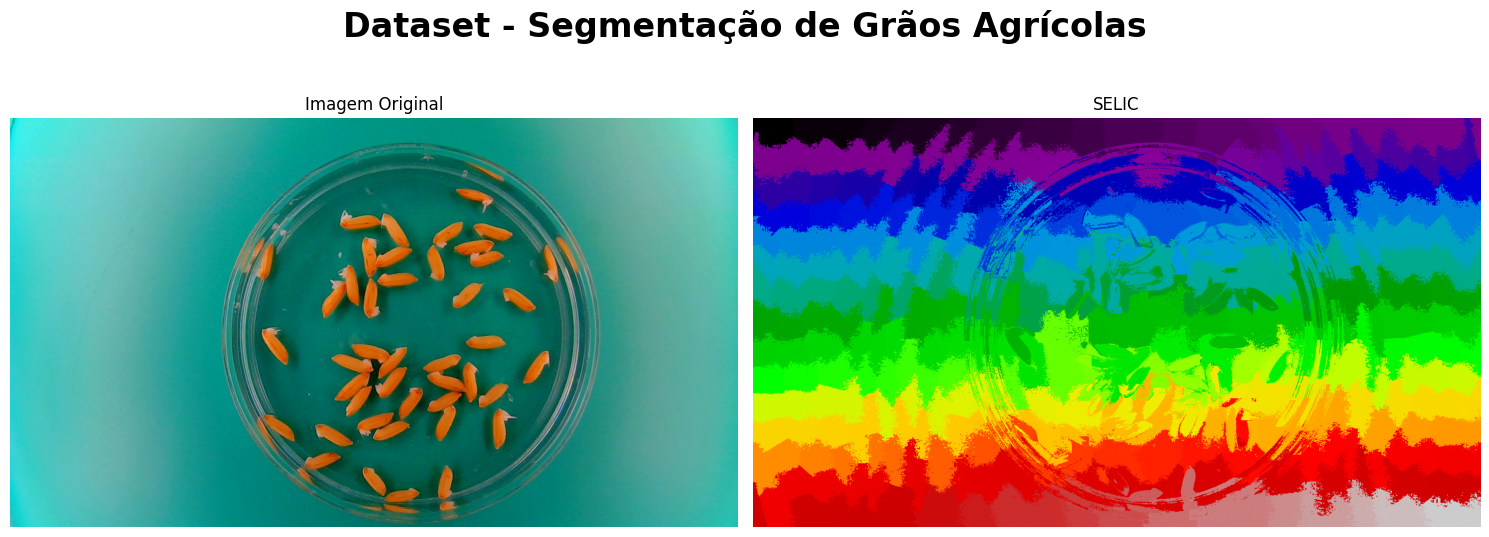

In [29]:
# imagem simples
image = np.random.randint(0, 255, (100, 100), dtype=np.uint8)
#img_path = 'data/test/aa.png'
img_path = 'data/dataset_seeds/0001.jpg' #'data/test/aa.png'
img = cv2.cvtColor(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB), cv2.COLOR_RGB2GRAY) 
img_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)


labels = slic(
    img, 
    num_superpixels=400, 
    m=5,
    max_iter=10
)

print(labels.shape)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Dataset - Segmentação de Grãos Agrícolas" , fontsize=24, fontweight='bold')

axes[0].imshow(img_rgb, cmap='gray')
axes[0].set_title(f'Imagem Original')
axes[0].axis('off')

axes[1].imshow(labels, cmap='nipy_spectral')
axes[1].set_title(f'SELIC')
axes[1].axis('off')

plt.tight_layout()
plt.show()